## 1. Build 500m x 500m NYC Grid

In [403]:
import geopandas as gpd
import numpy as np
from shapely.geometry import box

nyc = gpd.read_file(r"C:\Users\szaha\Downloads\Borough_Boundaries_20260328.geojson")

In [404]:
nyc = nyc.to_crs(epsg=32618)

In [405]:
nyc_union = nyc.dissolve()
nyc_union = nyc_union.reset_index(drop=True)

In [406]:
xmin, ymin, xmax, ymax = nyc_union.total_bounds
print(xmin, ymin, xmax, ymax)

563069.6710568516 4483098.0464451285 609762.252829007 4529951.986032876


In [407]:
cell_size = 500  # meters

grid_cells = []
for x in np.arange(xmin, xmax, cell_size):
    for y in np.arange(ymin, ymax, cell_size):
        grid_cells.append(box(x, y, x + cell_size, y + cell_size))

grid = gpd.GeoDataFrame(geometry=grid_cells, crs=nyc_union.crs)
grid.head()

,geometry
0,"POLYGON ((563569.671 4483098.046, 563569.671 4..."
1,"POLYGON ((563569.671 4483598.046, 563569.671 4..."
2,"POLYGON ((563569.671 4484098.046, 563569.671 4..."
3,"POLYGON ((563569.671 4484598.046, 563569.671 4..."
4,"POLYGON ((563569.671 4485098.046, 563569.671 4..."


In [408]:
grid_clipped = gpd.overlay(grid, nyc_union, how="intersection")
grid_clipped["grid_id"] = range(len(grid_clipped))
grid_clipped.head()

,:id,:version,:created_at,:updated_at,borocode,boroname,shape_area,shape_leng,geometry,grid_id
0,row-sn28~av3k.vwsa,rv-665b-x5bf.pjx5,2026-03-09 20:59:40.758000+00:00,2026-03-09 20:59:40.758000+00:00,5,Staten Island,1623618358.46,325912.288988,"POLYGON ((563569.671 4483598.046, 563569.671 4...",0
1,row-sn28~av3k.vwsa,rv-665b-x5bf.pjx5,2026-03-09 20:59:40.758000+00:00,2026-03-09 20:59:40.758000+00:00,5,Staten Island,1623618358.46,325912.288988,"POLYGON ((563569.671 4484098.046, 563569.671 4...",1
2,row-sn28~av3k.vwsa,rv-665b-x5bf.pjx5,2026-03-09 20:59:40.758000+00:00,2026-03-09 20:59:40.758000+00:00,5,Staten Island,1623618358.46,325912.288988,"POLYGON ((563569.671 4484598.046, 563569.671 4...",2
3,row-sn28~av3k.vwsa,rv-665b-x5bf.pjx5,2026-03-09 20:59:40.758000+00:00,2026-03-09 20:59:40.758000+00:00,5,Staten Island,1623618358.46,325912.288988,"MULTIPOLYGON (((563569.671 4485098.046, 563569...",3
4,row-sn28~av3k.vwsa,rv-665b-x5bf.pjx5,2026-03-09 20:59:40.758000+00:00,2026-03-09 20:59:40.758000+00:00,5,Staten Island,1623618358.46,325912.288988,"MULTIPOLYGON (((563569.671 4485098.046, 563408...",4


<Axes: >

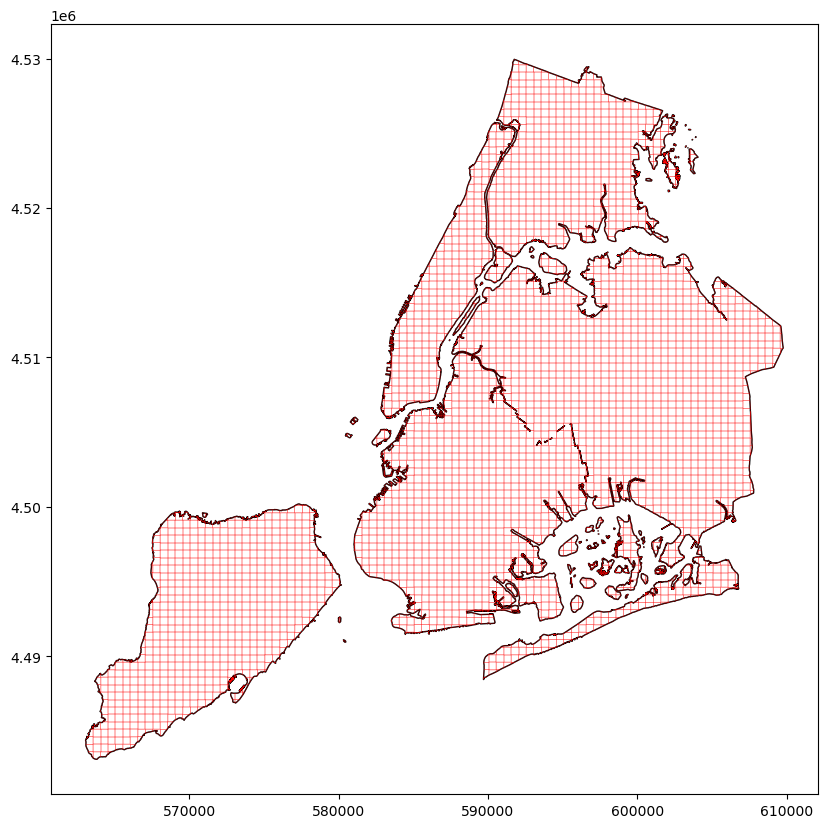

In [409]:
ax = nyc_union.plot(figsize=(10, 10), edgecolor="black", facecolor="none")
grid_clipped.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=0.2)

## 2. Feature Engineering: Temporal 311 Complaint Features

In [410]:
import pandas as pd

# Load 311 complaints and convert to GeoDataFrame (reproject to match grid)
df = pd.read_csv(r"C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\cleaned_311_points.csv")

gdf_complaints = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=32618)

print(f"{len(gdf_complaints):,} complaints loaded")

49,191 complaints loaded


In [411]:
# Assign each complaint to a grid cell via spatial join
joined = gpd.sjoin(
    gdf_complaints,
    grid_clipped[["grid_id", "geometry"]],
    how="left",
    predicate="within"
)

# Drop complaints that fell outside the grid (e.g. on water)
joined = joined.dropna(subset=["grid_id"])
joined["grid_id"] = joined["grid_id"].astype(int)

print(f"{joined['grid_id'].nunique():,} grid cells have at least one complaint")

2,721 grid cells have at least one complaint


In [412]:
# Monthly complaint count per grid cell
monthly_counts = (
    joined.groupby(["grid_id", "year_month"])
    .size()
    .reset_index(name="complaint_count")
)

monthly_counts.head()

,grid_id,year_month,complaint_count
0,1,2020-05,1
1,2,2021-03,1
2,2,2021-10,6
3,2,2023-07,1
4,2,2024-04,1


In [413]:
# Build a complete panel: every grid_id x every year_month
# Ensures cells with zero complaints still appear as rows
all_months = sorted(monthly_counts["year_month"].unique())
all_grid_ids = grid_clipped["grid_id"].unique()

panel_index = pd.MultiIndex.from_product(
    [all_grid_ids, all_months],
    names=["grid_id", "year_month"]
)
panel_df = pd.DataFrame(index=panel_index).reset_index()

panel_df = panel_df.merge(monthly_counts, on=["grid_id", "year_month"], how="left")
panel_df["complaint_count"] = panel_df["complaint_count"].fillna(0).astype(int)
panel_df = panel_df.sort_values(["grid_id", "year_month"]).reset_index(drop=True)

print(f"Panel shape: {panel_df.shape}  ({panel_df['grid_id'].nunique():,} cells x {len(all_months)} months)")
panel_df.head(10)

Panel shape: (263978, 3)  (3,718 cells x 71 months)


,grid_id,year_month,complaint_count
0,0,2020-01,0
1,0,2020-02,0
2,0,2020-03,0
3,0,2020-04,0
4,0,2020-05,0
5,0,2020-06,0
6,0,2020-07,0
7,0,2020-08,0
8,0,2020-09,0
9,0,2020-10,0


In [414]:
# Feature: month (calendar month 1-12)
panel_df["month"] = pd.to_datetime(panel_df["year_month"]).dt.month

# Feature: prior_month_complaints
# Complaint count in the single previous month for the same grid cell
panel_df["prior_month_complaints"] = (
    panel_df.groupby("grid_id")["complaint_count"]
    .shift(1)
    .fillna(0)
    .astype(int)
)

# Feature: complaints_in_last_3months
# Rolling sum of the 3 months *before* the current month (shift prevents leakage)
panel_df["complaints_in_last_3months"] = (
    panel_df.groupby("grid_id")["complaint_count"]
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).sum())
    .fillna(0)
    .astype(int)
)

panel_df[["grid_id", "year_month", "month", "complaint_count",
          "prior_month_complaints", "complaints_in_last_3months"]].head(12)

,grid_id,year_month,month,complaint_count,prior_month_complaints,complaints_in_last_3months
0,0,2020-01,1,0,0,0
1,0,2020-02,2,0,0,0
2,0,2020-03,3,0,0,0
3,0,2020-04,4,0,0,0
4,0,2020-05,5,0,0,0
5,0,2020-06,6,0,0,0
6,0,2020-07,7,0,0,0
7,0,2020-08,8,0,0,0
8,0,2020-09,9,0,0,0
9,0,2020-10,10,0,0,0


In [415]:
# Sanity check: pick the most active cell and verify rolling values look correct
sample_id = monthly_counts.groupby("grid_id")["complaint_count"].sum().idxmax()
panel_df[panel_df["grid_id"] == sample_id][
    ["year_month", "month", "complaint_count",
     "prior_month_complaints", "complaints_in_last_3months"]
]

,year_month,month,complaint_count,prior_month_complaints,complaints_in_last_3months
63616,2020-01,1,3,0,0
63617,2020-02,2,3,3,3
63618,2020-03,3,0,3,6
63619,2020-04,4,2,0,6
63620,2020-05,5,0,2,5
...,...,...,...,...,...
63682,2025-07,7,0,0,3
63683,2025-08,8,5,0,0
63684,2025-09,9,2,5,5
63685,2025-10,10,0,2,7


In [416]:
output_path = r"C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\features_311_grid.csv"
panel_df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\features_311_grid.csv


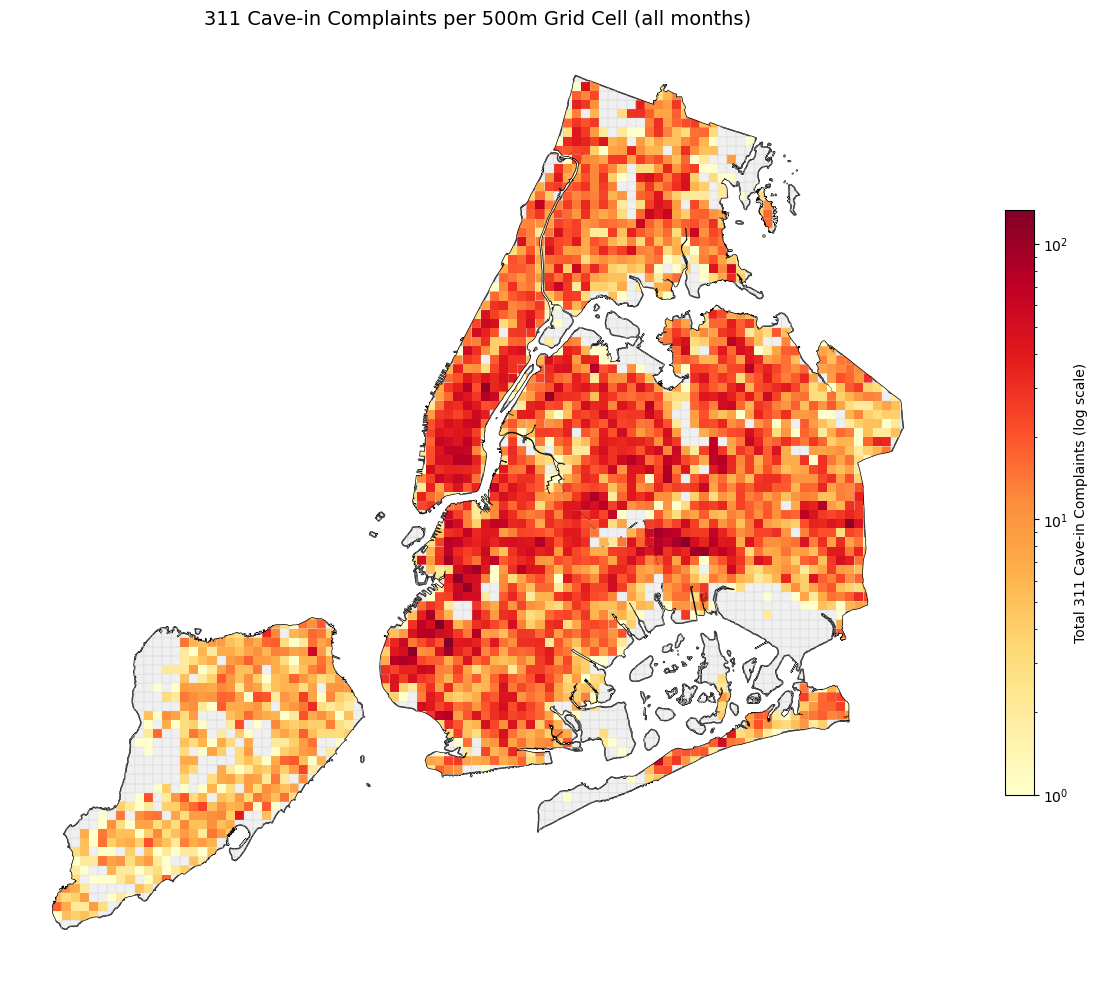

In [417]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Aggregate total complaints per grid cell across all months
total_by_cell = (
    panel_df.groupby("grid_id")["complaint_count"]
    .sum()
    .reset_index(name="total_complaints")
)

# Join counts onto the grid geometry
grid_plot = grid_clipped.merge(total_by_cell, on="grid_id", how="left")
grid_plot["total_complaints"] = grid_plot["total_complaints"].fillna(0)

fig, ax = plt.subplots(figsize=(12, 12))

# Base layer: NYC outline
nyc_union.plot(ax=ax, facecolor="#f0f0f0", edgecolor="black", linewidth=1)

# Choropleth: cells coloured by total complaint count (log scale)
grid_plot[grid_plot["total_complaints"] > 0].plot(
    ax=ax,
    column="total_complaints",
    cmap="YlOrRd",
    norm=LogNorm(
        vmin=grid_plot["total_complaints"].replace(0, float("nan")).min(),
        vmax=grid_plot["total_complaints"].max()
    ),
    edgecolor="none",
    legend=True,
    legend_kwds={"label": "Total 311 Cave-in Complaints (log scale)", "shrink": 0.5}
)

# Empty cells: faint outline only
grid_plot[grid_plot["total_complaints"] == 0].plot(
    ax=ax, facecolor="none", edgecolor="lightgray", linewidth=0.2
)

ax.set_title("311 Cave-in Complaints per 500m Grid Cell (all months)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 3. Feature Engineering: Water Main Breaks

In [418]:
# Load water main breaks and convert to GeoDataFrame (reproject to match grid)
df_water = pd.read_csv(r"C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\cleaned_water.csv")

# Normalize column name to lowercase immediately to match other datasets
df_water = df_water.rename(columns={"Year_Month": "year_month"})

gdf_water = gpd.GeoDataFrame(
    df_water,
    geometry=gpd.points_from_xy(df_water["Longitude"], df_water["Latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=32618)

print(f"{len(gdf_water):,} water main break records loaded")

20,757 water main break records loaded


In [419]:
# Assign each water main break to a grid cell via spatial join
water_joined = gpd.sjoin(
    gdf_water,
    grid_clipped[["grid_id", "geometry"]],
    how="left",
    predicate="within"
)

water_joined = water_joined.dropna(subset=["grid_id"])
water_joined["grid_id"] = water_joined["grid_id"].astype(int)

print(f"{water_joined['grid_id'].nunique():,} grid cells have at least one water main break")

2,456 grid cells have at least one water main break


In [420]:
# Monthly break count per grid cell
water_monthly = (
    water_joined.groupby(["grid_id", "year_month"])
    .size()
    .reset_index(name="break_count")
)

water_monthly.head()

,grid_id,year_month,break_count
0,1,2020-06,1
1,2,2021-01,3
2,2,2022-08,1
3,2,2022-12,3
4,3,2022-01,1


In [421]:
# Build complete panel: every grid_id x every year_month
water_all_months = sorted(water_monthly["year_month"].unique())
water_all_grid_ids = grid_clipped["grid_id"].unique()

water_panel_index = pd.MultiIndex.from_product(
    [water_all_grid_ids, water_all_months],
    names=["grid_id", "year_month"]
)
water_panel = pd.DataFrame(index=water_panel_index).reset_index()

water_panel = water_panel.merge(water_monthly, on=["grid_id", "year_month"], how="left")
water_panel["break_count"] = water_panel["break_count"].fillna(0).astype(int)
water_panel = water_panel.sort_values(["grid_id", "year_month"]).reset_index(drop=True)

print(f"Panel shape: {water_panel.shape}  ({water_panel['grid_id'].nunique():,} cells x {len(water_all_months)} months)")
water_panel.head(10)

Panel shape: (263978, 3)  (3,718 cells x 71 months)


,grid_id,year_month,break_count
0,0,2020-01,0
1,0,2020-02,0
2,0,2020-03,0
3,0,2020-04,0
4,0,2020-05,0
5,0,2020-06,0
6,0,2020-07,0
7,0,2020-08,0
8,0,2020-09,0
9,0,2020-10,0


In [422]:
# Feature: breaks_last_month
# Previous month's water main break count â€” shift(1) avoids leakage
water_panel["breaks_last_month"] = (
    water_panel.groupby("grid_id")["break_count"]
    .shift(1)
    .fillna(0)
    .astype(int)
)

# Feature: breaks_last_3_months
# Rolling sum of breaks over the 3 months *before* the current month
water_panel["breaks_last_3_months"] = (
    water_panel.groupby("grid_id")["break_count"]
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).sum())
    .fillna(0)
    .astype(int)
)

water_panel[["grid_id", "year_month", "breaks_last_month", "breaks_last_3_months"]].head(12)

,grid_id,year_month,breaks_last_month,breaks_last_3_months
0,0,2020-01,0,0
1,0,2020-02,0,0
2,0,2020-03,0,0
3,0,2020-04,0,0
4,0,2020-05,0,0
5,0,2020-06,0,0
6,0,2020-07,0,0
7,0,2020-08,0,0
8,0,2020-09,0,0
9,0,2020-10,0,0


In [423]:
# Sanity check: verify rolling values on the most active cell
water_top_cell = water_monthly.groupby("grid_id")["break_count"].sum().idxmax()
water_panel[water_panel["grid_id"] == water_top_cell][
    ["year_month", "breaks_last_month", "breaks_last_3_months"]
]

,year_month,breaks_last_month,breaks_last_3_months
177216,2020-01,0,0
177217,2020-02,0,0
177218,2020-03,3,3
177219,2020-04,1,4
177220,2020-05,0,4
...,...,...,...
177282,2025-07,2,2
177283,2025-08,0,2
177284,2025-09,0,2
177285,2025-10,0,0


In [424]:
output_path = r"C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\features_water_grid.csv"
water_panel.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\features_water_grid.csv


## 4. Feature Engineering: Precipitation

In [425]:
# Load precipitation data (single Central Park station â€” daily readings)
df_prcp = pd.read_csv(r"C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\cleaned_precipitation.csv")

# Sum daily PRCP to monthly totals (keep full series for correct rolling)
monthly_rain = (
    df_prcp.groupby("Year_Month")["PRCP"]
    .sum()
    .reset_index(name="monthly_rain")
    .rename(columns={"Year_Month": "year_month"})
    .sort_values("year_month")
    .reset_index(drop=True)
)

print(f"{len(monthly_rain)} months loaded ({monthly_rain['year_month'].min()} to {monthly_rain['year_month'].max()})")
monthly_rain.head()

191 months loaded (2010-01 to 2025-11)


,year_month,monthly_rain
0,2010-01,2.08
1,2010-02,6.69
2,2010-03,10.69
3,2010-04,2.99
4,2010-05,3.01


In [426]:
# Compute rain_last_3_months on the FULL series before clipping
# This ensures 2020-01 correctly uses Oct/Nov/Dec 2019 in its rolling window
monthly_rain["rain_last_3_months"] = (
    monthly_rain["monthly_rain"]
    .shift(1)
    .rolling(window=3, min_periods=1)
    .sum()
    .fillna(0)
)

# Now clip to common date range shared with 311 and water datasets
monthly_rain = (
    monthly_rain[
        (monthly_rain["year_month"] >= "2020-01") &
        (monthly_rain["year_month"] <= "2025-11")
    ]
    .reset_index(drop=True)
)

print(f"{len(monthly_rain)} months after clipping ({monthly_rain['year_month'].min()} to {monthly_rain['year_month'].max()})")
monthly_rain.head(6)

71 months after clipping (2020-01 to 2025-11)


,year_month,monthly_rain,rain_last_3_months
0,2020-01,1.93,15.19
1,2020-02,2.54,10.97
2,2020-03,3.78,11.56
3,2020-04,4.49,8.25
4,2020-05,1.65,10.81
5,2020-06,1.76,9.92


In [427]:
# Broadcast to all grid cells
# Precipitation is city-wide (one station), so every grid cell gets the same value per month
all_grid_ids = grid_clipped["grid_id"].unique()

prcp_panel = (
    pd.MultiIndex.from_product(
        [all_grid_ids, monthly_rain["year_month"].tolist()],
        names=["grid_id", "year_month"]
    )
    .to_frame(index=False)
)

prcp_panel = prcp_panel.merge(monthly_rain, on="year_month", how="left")
prcp_panel = prcp_panel.sort_values(["grid_id", "year_month"]).reset_index(drop=True)

print(f"Panel shape: {prcp_panel.shape}  ({prcp_panel['grid_id'].nunique():,} cells x {monthly_rain.shape[0]} months)")
prcp_panel.head(10)

Panel shape: (263978, 4)  (3,718 cells x 71 months)


,grid_id,year_month,monthly_rain,rain_last_3_months
0,0,2020-01,1.93,15.19
1,0,2020-02,2.54,10.97
2,0,2020-03,3.78,11.56
3,0,2020-04,4.49,8.25
4,0,2020-05,1.65,10.81
5,0,2020-06,1.76,9.92
6,0,2020-07,6.58,7.90
7,0,2020-08,5.03,9.99
8,0,2020-09,3.94,13.37
9,0,2020-10,5.05,15.55


In [428]:
output_path = r"C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\features_precipitation_grid.csv"
prcp_panel.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\features_precipitation_grid.csv


## 5. Feature Engineering: Bedrock Depth & Elevation

In [429]:
# Load cleaned bedrock data and convert to GeoDataFrame
df_bedrock = pd.read_csv(r"C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\cleaned_bedrock.csv")

gdf_bedrock = gpd.GeoDataFrame(
    df_bedrock,
    geometry=gpd.points_from_xy(df_bedrock["longitude"], df_bedrock["latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=32618)

print(f"{len(gdf_bedrock):,} bedrock borehole points loaded")

186 bedrock borehole points loaded


In [430]:
# Step 1: Direct spatial join â€” boreholes that fall within a grid cell
bedrock_direct = gpd.sjoin(
    gdf_bedrock,
    grid_clipped[["grid_id", "geometry"]],
    how="inner",
    predicate="within"
)

# For cells with multiple boreholes, take the mean
bedrock_direct = (
    bedrock_direct.groupby("grid_id")[["elev_ft", "depth_ft"]]
    .mean()
    .reset_index()
)

print(f"{len(bedrock_direct):,} grid cells have a direct borehole hit")
print(f"{len(grid_clipped) - len(bedrock_direct):,} grid cells need nearest-neighbour fill")

161 grid cells have a direct borehole hit
3,557 grid cells need nearest-neighbour fill


In [431]:
# Step 2: Nearest-neighbour fill for cells with no direct borehole
# Use grid cell centroids and find the closest borehole for each
grid_centroids = grid_clipped[["grid_id", "geometry"]].copy()
grid_centroids["geometry"] = grid_centroids.geometry.centroid

# Only fill cells that didn't get a direct hit
cells_needing_fill = grid_centroids[
    ~grid_centroids["grid_id"].isin(bedrock_direct["grid_id"])
]

bedrock_nn = gpd.sjoin_nearest(
    cells_needing_fill,
    gdf_bedrock[["elev_ft", "depth_ft", "geometry"]],
    how="left"
)[["grid_id", "elev_ft", "depth_ft"]]

print(f"{len(bedrock_nn):,} cells filled via nearest neighbour")

3,557 cells filled via nearest neighbour


In [432]:
# Step 3: Combine direct hits and nearest-neighbour fills
bedrock_grid = (
    pd.concat([bedrock_direct, bedrock_nn], ignore_index=True)
    .sort_values("grid_id")
    .reset_index(drop=True)
)

# Round to 4 decimal places
bedrock_grid["elev_ft"]  = bedrock_grid["elev_ft"].round(4)
bedrock_grid["depth_ft"] = bedrock_grid["depth_ft"].round(4)

print(f"Final bedrock grid shape: {bedrock_grid.shape}")
print(f"Null check:\n{bedrock_grid.isnull().sum()}")
bedrock_grid.head(10)

Final bedrock grid shape: (3718, 3)
Null check:
grid_id     0
elev_ft     0
depth_ft    0
dtype: int64


,grid_id,elev_ft,depth_ft
0,0,-211.05,343.05
1,1,-211.05,343.05
2,2,-211.05,343.05
3,3,-211.05,343.05
4,4,-211.05,343.05
5,5,-211.05,343.05
6,6,-211.05,343.05
7,7,-211.05,343.05
8,8,-211.05,343.05
9,9,-211.05,343.05


In [433]:
output_path = r"C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\features_bedrock_grid.csv"
bedrock_grid.to_csv(output_path, index=False)
print(f"Saved to {output_path}")
print()
print("NOTE: bedrock features are static (no time dimension).")
print("When building the model, merge features_bedrock_grid.csv on grid_id only.")

Saved to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\features_bedrock_grid.csv

NOTE: bedrock features are static (no time dimension).
When building the model, merge features_bedrock_grid.csv on grid_id only.


## 6. Feature Engineering: Pavement Rating

In [434]:
# Load cleaned pavement data and convert to GeoDataFrame
df_pave = pd.read_csv(r"C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\cleaned_pavement.csv")

gdf_pave = gpd.GeoDataFrame(
    df_pave,
    geometry=gpd.points_from_xy(df_pave["longitude"], df_pave["latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=32618)

print(f"{len(gdf_pave):,} pavement inspection records loaded")

320,482 pavement inspection records loaded


In [435]:
# Assign each inspection to a grid cell via spatial join
pave_joined = gpd.sjoin(
    gdf_pave,
    grid_clipped[["grid_id", "geometry"]],
    how="left",
    predicate="within"
)

pave_joined = pave_joined.dropna(subset=["grid_id"])
pave_joined["grid_id"] = pave_joined["grid_id"].astype(int)

print(f"{pave_joined['grid_id'].nunique():,} grid cells have at least one inspection")

2,948 grid cells have at least one inspection


In [436]:
# Average system_rating per grid cell per month
# (multiple inspection points may fall in the same cell in the same month)
pave_monthly = (
    pave_joined.groupby(["grid_id", "year_month"])["system_rating"]
    .mean()
    .reset_index(name="pavement_rating")
)

pave_monthly["pavement_rating"] = pave_monthly["pavement_rating"].round(4)
print(f"{len(pave_monthly):,} grid-cell/month combinations with a rating")
pave_monthly.head()

51,655 grid-cell/month combinations with a rating


,grid_id,year_month,pavement_rating
0,0,2022-01,0.0
1,1,2020-03,0.0
2,1,2020-04,0.0
3,1,2020-05,0.0
4,1,2020-06,0.0


In [437]:
# Build complete panel: every grid_id x every year_month
pave_all_months = sorted(pave_monthly["year_month"].unique())
pave_all_grid_ids = grid_clipped["grid_id"].unique()

pave_panel_index = pd.MultiIndex.from_product(
    [pave_all_grid_ids, pave_all_months],
    names=["grid_id", "year_month"]
)
pave_panel = pd.DataFrame(index=pave_panel_index).reset_index()

pave_panel = pave_panel.merge(pave_monthly, on=["grid_id", "year_month"], how="left")
pave_panel = pave_panel.sort_values(["grid_id", "year_month"]).reset_index(drop=True)

print(f"Panel shape before fill: {pave_panel.shape}")
print(f"Missing pavement_rating: {pave_panel['pavement_rating'].isna().sum():,} rows")

Panel shape before fill: (256542, 3)
Missing pavement_rating: 204,887 rows


In [438]:
# Forward-fill within each grid cell:
# Ratings are periodic — carry the last known rating forward until a new inspection occurs
pave_panel["pavement_rating"] = (
    pave_panel.groupby("grid_id")["pavement_rating"]
    .transform(lambda x: x.ffill())
)

# For cells that were never inspected, fill with the city-wide mean rating
citywide_mean = pave_monthly["pavement_rating"].mean().round(4)
pave_panel["pavement_rating"] = pave_panel["pavement_rating"].fillna(citywide_mean)

print(f"City-wide mean rating used for unfilled cells: {citywide_mean}")
print(f"Missing after fill: {pave_panel['pavement_rating'].isna().sum()}")
pave_panel.head(12)

City-wide mean rating used for unfilled cells: 6.4991
Missing after fill: 0


,grid_id,year_month,pavement_rating
0,0,2020-01,6.4991
1,0,2020-02,6.4991
2,0,2020-03,6.4991
3,0,2020-04,6.4991
4,0,2020-05,6.4991
5,0,2020-06,6.4991
6,0,2020-07,6.4991
7,0,2020-08,6.4991
8,0,2020-09,6.4991
9,0,2020-10,6.4991


In [439]:
output_path = r"C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\features_pavement_grid.csv"
pave_panel.to_csv(output_path, index=False)
print(f"Saved {len(pave_panel):,} rows to {output_path}")

Saved 256,542 rows to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\features_pavement_grid.csv


## 7. Feature Engineering: Neighboring Cell Features

In [440]:
# Build a neighbor lookup table for the 500m grid
# Strategy: buffer each cell by 1m — any cell whose original geometry
# intersects the buffer is a neighbor (shares an edge or corner)
grid_buf = grid_clipped[['grid_id', 'geometry']].copy()
grid_buf['geometry'] = grid_buf.geometry.buffer(1)

neighbor_join = gpd.sjoin(
    grid_buf.rename(columns={'grid_id': 'neighbor_id'}),
    grid_clipped[['grid_id', 'geometry']],
    how='inner',
    predicate='intersects'
)

# Remove self-joins (a cell is not its own neighbor)
neighbors = (
    neighbor_join[neighbor_join['neighbor_id'] != neighbor_join['grid_id']]
    [['grid_id', 'neighbor_id']]
    .reset_index(drop=True)
)

print(f'Neighbor pairs built: {len(neighbors):,}')
print(f'Avg neighbors per cell: {len(neighbors) / grid_clipped["grid_id"].nunique():.1f}')

Neighbor pairs built: 26,334
Avg neighbors per cell: 7.1


In [441]:
# Feature: neighboring_sinkhole_incidents
# Sum of cave-in complaints in adjacent cells, lagged 1 month to avoid leakage

# Step 1: get raw monthly complaint counts per cell (already in panel_df)
complaints_raw = panel_df[['grid_id', 'year_month', 'complaint_count']].copy()

# Step 2: for each neighbor pair, pull the neighbor's complaint count
neighbor_complaints = (
    neighbors
    .merge(
        complaints_raw.rename(columns={'grid_id': 'neighbor_id', 'complaint_count': 'neighbor_count'}),
        on='neighbor_id'
    )
    .groupby(['grid_id', 'year_month'])['neighbor_count']
    .sum()
    .reset_index(name='neighbor_complaint_sum')
)

# Step 3: merge onto panel and lag by 1 month
panel_df = panel_df.merge(neighbor_complaints, on=['grid_id', 'year_month'], how='left')
panel_df['neighbor_complaint_sum'] = panel_df['neighbor_complaint_sum'].fillna(0)

panel_df['neighboring_sinkhole_incidents'] = (
    panel_df.groupby('grid_id')['neighbor_complaint_sum']
    .shift(1)
    .fillna(0)
    .astype(int)
)
panel_df = panel_df.drop(columns=['neighbor_complaint_sum'])

print('neighboring_sinkhole_incidents sample:')
panel_df[['grid_id','year_month','complaint_count','neighboring_sinkhole_incidents']].head(10)

neighboring_sinkhole_incidents sample:


,grid_id,year_month,complaint_count,neighboring_sinkhole_incidents
0,0,2020-01,0,0
1,0,2020-02,0,0
2,0,2020-03,0,0
3,0,2020-04,0,0
4,0,2020-05,0,0
5,0,2020-06,0,1
6,0,2020-07,0,0
7,0,2020-08,0,1
8,0,2020-09,0,1
9,0,2020-10,0,0


In [442]:
# Feature: neighboring_water_breaks
# Sum of water main breaks in adjacent cells, lagged 1 month to avoid leakage

# Pull raw monthly break counts from water panel
breaks_raw = water_panel[['grid_id', 'year_month', 'break_count']].copy()

neighbor_breaks = (
    neighbors
    .merge(
        breaks_raw.rename(columns={'grid_id': 'neighbor_id', 'break_count': 'neighbor_count'}),
        on='neighbor_id'
    )
    .groupby(['grid_id', 'year_month'])['neighbor_count']
    .sum()
    .reset_index(name='neighbor_break_sum')
)

panel_df = panel_df.merge(neighbor_breaks, on=['grid_id', 'year_month'], how='left')
panel_df['neighbor_break_sum'] = panel_df['neighbor_break_sum'].fillna(0)

panel_df['neighboring_water_breaks'] = (
    panel_df.groupby('grid_id')['neighbor_break_sum']
    .shift(1)
    .fillna(0)
    .astype(int)
)
panel_df = panel_df.drop(columns=['neighbor_break_sum'])

print('neighboring_water_breaks sample:')
panel_df[['grid_id','year_month','neighboring_sinkhole_incidents','neighboring_water_breaks']].head(10)

neighboring_water_breaks sample:


,grid_id,year_month,neighboring_sinkhole_incidents,neighboring_water_breaks
0,0,2020-01,0,0
1,0,2020-02,0,0
2,0,2020-03,0,0
3,0,2020-04,0,0
4,0,2020-05,0,0
5,0,2020-06,1,0
6,0,2020-07,0,1
7,0,2020-08,1,0
8,0,2020-09,1,0
9,0,2020-10,0,1


In [443]:
# Save updated 311 panel (now includes neighbor features)
output_path = r'C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\features_311_grid.csv'
panel_df.to_csv(output_path, index=False)
print(f'Updated features_311_grid.csv saved — columns: {list(panel_df.columns)}')

Updated features_311_grid.csv saved — columns: ['grid_id', 'year_month', 'complaint_count', 'month', 'prior_month_complaints', 'complaints_in_last_3months', 'neighboring_sinkhole_incidents', 'neighboring_water_breaks']
